<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; width: auto; max-width: 100%;">
<h1 style="color: white;"> ПРАКТИЧЕСКАЯ РАБОТА № 3</h1>

<h2 style="color: white;">Анализ цифровой зрелости подразделений и формирование ИТ-стратегии</h2>
</div>

---

## Цель работы

> Оценить уровень цифровой зрелости подразделений компании на основе количественных метрик и сформировать приоритезированный план ИТ-инвестиций для повышения операционной эффективности.

---

## Описание данных

Набор данных: **`digital_maturity_survey.csv`**

| Поле | Описание | Шкала |
|------|----------|-------|
| `department` | Название подразделения | Текст |
| `data_quality` | Качество данных и процессов управления ими | 1–5 |
| `automation_level` | Уровень автоматизации бизнес-процессов | 1–5 |
| `analytics_capability` | Развитость аналитических компетенций и инструментов | 1–5 |
| `it_infra_rating` | Оценка надёжности и современности ИТ-инфраструктуры | 1–5 |

---

## Методология оценки

### 1. Интегральный показатель цифровой зрелости

Для каждого подразделения рассчитывается среднее арифметическое по четырём критериям:

maturity_score = (data_quality + automation_level + analytics_capability + it_infra_rating) / 4


### 2. Классификация уровней зрелости

| Уровень | Диапазон score | Интерпретация |
|---------|----------------|----------------|
| **Низкий** | ≤ 2.5 | Требует срочных инвестиций |
| **Средний** | 2.6 – 3.8 | Точечные улучшения |
| **Высокий** | > 3.8 | Поддержка и масштабирование |

### 3. Приоритет инвестиций

priority = (4.0 - maturity_score) × department_size_weight


где `department_size_weight` учитывает численность подразделения (чем больше — тем выше приоритет).

---

## Уровни зрелости

| Уровень | Тип проекта | Стоимость (руб.) | Ожидаемый эффект (к score) |
|---------|-------------|------------------|----------------------------|
| **Низкий** | Внедрение DQ-мониторинга | 800 000 – 1 500 000 | +0.8 – 1.2 |
| **Низкий** | Базовая автоматизация (RPA) | 1 200 000 – 2 500 000 | +1.0 – 1.5 |
| **Средний** | Внедрение BI-панелей | 600 000 – 1 200 000 | +0.5 – 0.9 |
| **Средний** | Модернизация инфраструктуры | 1 000 000 – 2 000 000 | +0.6 – 1.1 |

---

## Задачи практической работы

1. **Загрузка и предобработка данных**: Проверить данные на пропуски и аномалии (шкала 1–5), при необходимости выполнить очистку.
2. **Расчёт интегрального показателя**: Вычислить `maturity_score` для каждой записи.
3. **Группировка по подразделениям**: Рассчитать средний `maturity_score` для каждого отдела.
4. **Классификация**: Отнести каждое подразделение к низкому, среднему или высокому уровню зрелости.
5. **Формирование рекомендаций**: Для подразделений с низким и средним уровнем подобрать типовые ИТ-проекты с указанием стоимости и ожидаемого эффекта.
6. **Корреляционный анализ**: Построить тепловую карту корреляций между четырьмя критериями зрелости.
7. **Расчёт приоритета инвестиций**: Приоритет инвестиций для каждого подразделения рассчитывается с учётом текущего уровня зрелости и численности отдела

---


## Ожидаемый результат

Результатом работы является:

- **Очищенный и подготовленный набор данных**.
- **Таблица средних показателей зрелости по подразделениям** с классификацией.
- **Тепловая карта корреляций** между критериями.
- **Итоговая таблица рекомендаций** с проектами, стоимостью и приоритетом.
- **Визуализации** распределения уровней зрелости и топ‑3 приоритетных отделов.
- **Аналитические выводы** для стратегического планирования ИТ-инвестиций.

---



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Загрузка данных

Выполняется загрузка исходного датасета с информацией о завершенных ИТ-проектах компании.

```python
data1_df = pd.read_csv("it_portfolio_pr")



In [16]:
data1_df = pd.read_csv("digital_maturity_survey.csv")

#### Первичный просмотр данных

Смотрим первый 10 строк 

```python
data1_df.head(10)

In [17]:
data1_df.head(10)

,department,data_quality,automation_level,analytics_capability,it_infra_rating
0,IT Department,4,4,5,5
1,IT Department,4,4,3,4
2,IT Department,4,5,3,4
3,IT Department,4,4,3,4
4,IT Department,4,5,3,5
5,IT Department,5,4,3,5
6,IT Department,5,5,3,4
7,IT Department,5,4,3,5
8,IT Department,4,5,4,5
9,IT Department,4,5,5,4


#### Первичная проверка данных

```python
# Размер датасета
print("Размер датасета:", data1_df.shape)

# Информация о столбцах и типах данных
data1_df.info()

# Проверка пропусков
print(data1_df.isnull().sum())

# Статистическое описание
data1_df.describe()

In [18]:
print("Размер датасета:", data1_df.shape)
print("\n")
data1_df.info()
print("\n")
print(data1_df.isnull().sum())
print("\n")
data1_df.describe()

Размер датасета: (80, 5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   department            80 non-null     object
 1   data_quality          80 non-null     int64 
 2   automation_level      80 non-null     int64 
 3   analytics_capability  80 non-null     int64 
 4   it_infra_rating       80 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 3.2+ KB


department              0
data_quality            0
automation_level        0
analytics_capability    0
it_infra_rating         0
dtype: int64




,data_quality,automation_level,analytics_capability,it_infra_rating
count,80.000000,80.000000,80.000000,80.000000
mean,3.012500,2.550000,2.325000,3.487500
std,1.237533,1.261905,1.016011,0.967755
min,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,2.000000,3.000000
50%,3.000000,3.000000,2.000000,4.000000
75%,4.000000,3.250000,3.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


#### Проверка диапазона значений критериев

Для каждого из четырёх критериев цифровой зрелости выполняется проверка соответствия шкале 1–5.

In [19]:
for col in ['data_quality', 'automation_level', 'analytics_capability', 'it_infra_rating']:
    min_val = data1_df[col].min()
    max_val = data1_df[col].max()
    print(f"{col}: диапазон [{min_val}, {max_val}]")

data_quality: диапазон [1, 5]
automation_level: диапазон [1, 5]
analytics_capability: диапазон [1, 5]
it_infra_rating: диапазон [2, 5]


## 3. Расчёт интегрального показателя цифровой зрелости

Показатели `data_quality`, `automation_level`, `analytics_capability` и `it_infra_rating` суммируются и усредняются для получения интегральной оценки цифровой зрелости:

$$maturity\_score = \frac{data\_quality + automation\_level + analytics\_capability + it\_infra\_rating}{4}$$

Это необходимо для получения единой количественной оценки уровня цифровой зрелости каждого подразделения.



In [20]:
data1_df['maturity_score'] = (
    data1_df['data_quality'] + 
    data1_df['automation_level'] + 
    data1_df['analytics_capability'] + 
    data1_df['it_infra_rating']
) / 4

print(data1_df['maturity_score'])

0     4.50
1     3.75
2     4.00
3     3.75
4     4.25
      ... 
75    2.50
76    2.00
77    2.00
78    2.25
79    2.50
Name: maturity_score, Length: 80, dtype: float64


## 4. Группировка данных по подразделениям

Для каждого подразделения рассчитывается средний интегральный показатель `maturity_score`:

$$\overline{maturity\_score}_{dept} = \frac{1}{n}\sum_{i=1}^{n} maturity\_score_i$$

Это необходимо для получения обобщённой оценки уровня цифровой зрелости каждого отдела компании.


In [21]:
dept_maturity = data1_df.groupby('department')['maturity_score'].mean().reset_index()
dept_maturity.columns = ['department', 'avg_maturity_score']

## 5. Классификация подразделений по уровням зрелости

На основе среднего значения `avg_maturity_score` подразделения распределяются по трём категориям:

| Уровень | Диапазон | Интерпретация |
|---------|----------|----------------|
| **Низкий** | ≤ 2.5 | Требует срочных инвестиций |
| **Средний** | 2.6 – 3.8 | Точечные улучшения |
| **Высокий** | > 3.8 | Поддержка и масштабирование |

Это необходимо для дифференцированного подхода к планированию ИТ-инвестиций в зависимости от текущего уровня развития подразделения.


In [22]:
def classify(score):
    if score <= 2.5:
        return 'Низкий'
    elif score <= 3.8:
        return 'Средний'
    else:
        return 'Высокий'

dept_maturity['level'] = dept_maturity['avg_maturity_score'].apply(classify)

print(dept_maturity)

              department  avg_maturity_score    level
0       Customer Support               2.300   Низкий
1     Finance Department               3.525  Средний
2          HR Department               2.425   Низкий
3          IT Department               4.200  Высокий
4   Marketing Department               2.525  Средний
5  Operations Department               2.200   Низкий
6         R&D Department               2.200   Низкий
7       Sales Department               3.375  Средний


## 6. Тепловая карта корреляций

**Метод:** коэффициент корреляции Пирсона.

$$r_{xy} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

**Интерпретация значений:**
- `r > 0` — положительная связь (рост одного показателя ведёт к росту другого)
- `r < 0` — отрицательная связь (рост одного ведёт к снижению другого)
- `|r| > 0.5` — сильная корреляция
- `0.3 < |r| < 0.5` — умеренная корреляция
- `|r| < 0.3` — слабая корреляция

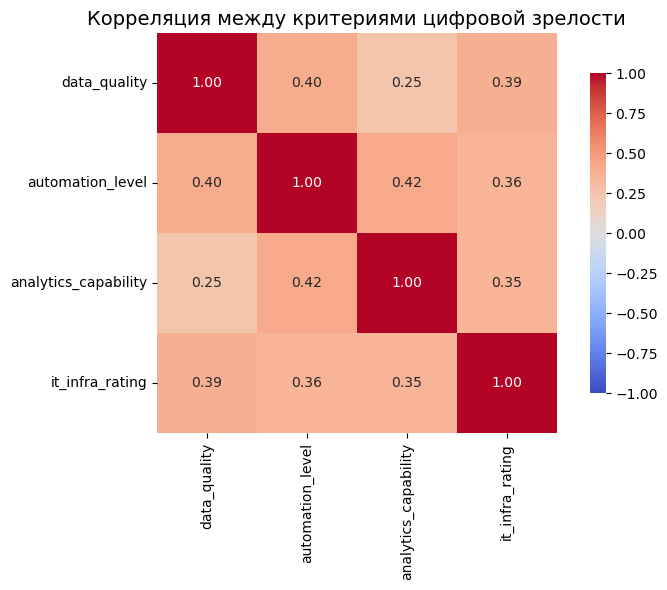

In [23]:
corr_cols = ['data_quality', 'automation_level', 'analytics_capability', 'it_infra_rating']

corr_matrix = data1_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,           
            cmap='coolwarm',      
            center=0,             
            vmin=-1, vmax=1,      
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Корреляция между критериями цифровой зрелости', fontsize=14)
plt.tight_layout()
plt.show()



## 7. Расчёт приоритета инвестиций

Приоритет инвестиций для каждого подразделения рассчитывается с учётом текущего уровня зрелости и численности отдела:

$$priority = (4.0 - maturity\_score) \times department\_size\_weight$$

где:
- `4.0` — максимально возможный уровень зрелости (целевой ориентир)
- `maturity_score` — текущий уровень зрелости подразделения
- `department_size_weight` — весовой коэффициент численности (чем больше отдел, тем выше приоритет)

Это необходимо для объективного распределения ограниченного бюджета ИТ-проектов с учётом масштаба влияния на бизнес.


In [24]:

size_weights = {
    'Operations Department': 1.5,
    'Customer Support': 1.3,
    'Sales Department': 1.2,
    'IT Department': 1.0,
    'Finance Department': 1.0,
    'HR Department': 0.8,
    'Marketing Department': 0.9,
    'R&D Department': 0.9
}

for idx, row in dept_maturity.iterrows():
    dept = row['department']  
    priority = (4.0 - row['avg_maturity_score']) * size_weights.get(dept, 1.0)  
    print(f"{dept}: priority = {priority}")

Customer Support: priority = 2.2100000000000004
Finance Department: priority = 0.4750000000000001
HR Department: priority = 1.2600000000000002
IT Department: priority = -0.20000000000000018
Marketing Department: priority = 1.3275000000000001
Operations Department: priority = 2.6999999999999997
R&D Department: priority = 1.6199999999999999
Sales Department: priority = 0.75
